# NF-Injections

Learn the density of parameters in GWTC-4 data, conditioned on some detection probability (FAR).

### Imports

In [1]:
import os
import h5py
import numpy as np
import pandas as pd
from scipy.special import logit, expit

import matplotlib.pyplot as plt
import corner

import jax
import jax.numpy as jnp
import optax
import equinox as eqx

# FlowJAX (new API)
from flowjax.flows import masked_autoregressive_flow
from flowjax.distributions import Normal

from pathlib import Path

import seaborn as sns
from tqdm import tqdm, trange

import utils as ut

# silence unnecessary warnings about some specific model not being available (shouldn't hurt performance according to ChatGPT)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [2]:
import os
import socket
print(f"Hostname: {socket.gethostname()}")
print(f"CUDA_VISIBLE_DEVICES: {os.environ.get('CUDA_VISIBLE_DEVICES')}")
!nvidia-smi

Hostname: usm-cl-nv01.hpc.physik.uni-muenchen.de
CUDA_VISIBLE_DEVICES: 0
Fri Feb 20 22:00:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.195.03             Driver Version: 570.195.03     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 NVL                On  |   00000000:07:00.0 Off |                    0 |
| N/A   35C    P0             61W /  400W |       0MiB /  95830MiB |      0%      Default |
|                                         |                        

In [3]:
jax.devices()

[CudaDevice(id=0)]

In [4]:
# load injection data
def read_data(file: str, gwtc_version: int) -> pd.DataFrame:
    # Load
    raw_injection_data = h5py.File(file, 'r')
    # injections now called events in gwtc4
    if gwtc_version == 3:
        events = raw_injection_data['injections']
        m1_key, m2_key, dist_key, redshift_key = "mass1", "mass2", "distance", "redshift"
    elif gwtc_version == 4:
        events = raw_injection_data["events"]
        m1_key, m2_key, dist_key, redshift_key = "mass1_detector", "mass2_detector", "luminosity_distance", "z"
    print("Data length:", len(events))

    # Read injection parameters
    injectionData = pd.DataFrame()
    injectionData['m1_detector'] = np.array(events[m1_key][()], dtype='float64')
    injectionData['m2_detector'] = np.array(events[m2_key][()], dtype='float64')
    injectionData['luminosity_distance'] = events[dist_key][()]/1000.  # Convert from Mpc to Gpc
    injectionData['cos_inclination'] = np.cos(events['inclination'])
    injectionData['right_ascension'] = events['right_ascension']
    injectionData['declination'] = events['declination']
    injectionData['polarization'] = events['polarization']
    injectionData['redshift'] = events[redshift_key][()]

    # add source-frame quantities
    injectionData["m1_source"] = injectionData['m1_detector'] / (1 + injectionData['redshift'])
    injectionData["m2_source"] = injectionData['m2_detector'] / (1 + injectionData['redshift'])
    
    # Some derived mass parameters
    injectionData['q'] = injectionData.m2_detector/injectionData.m1_detector
    injectionData['eta'] = injectionData.m1_detector*injectionData.m2_detector/(injectionData.m1_detector+injectionData.m2_detector)**2
    injectionData['chirp_mass_detector'] = injectionData.eta**(3./5.)*(injectionData.m1_detector+injectionData.m2_detector)
    injectionData['total_mass_detector'] = (injectionData.m1_detector+injectionData.m2_detector)

    # And some derived spin parameters
    s1x = np.array(events['spin1x'])
    s1y = np.array(events['spin1y'])
    s1z = np.array(events['spin1z'])
    s2x = np.array(events['spin2x'])
    s2y = np.array(events['spin2y'])
    s2z = np.array(events['spin2z'])
    injectionData['s1x'] = s1x
    injectionData['s1y'] = s1y
    injectionData['s1z'] = s1z
    injectionData['s2x'] = s2x
    injectionData['s2y'] = s2y
    injectionData['s2z'] = s2z
    injectionData['a1'] = np.sqrt(s1x**2 + s1y**2 + s1z**2)
    injectionData['a2'] = np.sqrt(s2x**2 + s2y**2 + s2z**2)
    injectionData['cost1'] = s1z/injectionData.a1
    injectionData['cost2'] = s2z/injectionData.a2
    injectionData['Xeff'] = (s1z + injectionData.q*s2z)/(1.+injectionData.q)
    injectionData['Xdiff'] = (s1z - injectionData.q*s2z)/(1.+injectionData.q)
    # injectionData['Xp_gen'] = generalized_Xp(s1x, s1y, s2x,  s2y, injectionData.q)
    
    if gwtc_version == 4:
        #changed in GWTC4
        far_min = np.min([events['%s_far'%search][:] for search in raw_injection_data.attrs['searches']], axis=0)

        """injectionData['p_draw'] = np.exp(raw_injection_data['lnpdraw_mass1_source_mass2_source_redshift_spin1x_spin1y_spin1z_spin2x_spin2y_spin2z'][:])/(1+injectionData['redshift'])**2/ddL_of_z(injectionData['redshift'],injectionData['luminosity_distance'],H0cosmo)
        T = (raw_injection_data.attrs['total_analysis_time'])/(3600.0*24.0*365.25) 
        injectionData['p_draw'] /= T
        
        
        injectionData['p_draw'] /= injectionData['weights'] # ädont think i should do this here"""

    injectionData['weights'] = events['weights'][()]
    injectionData['far_min'] = far_min
    injectionData['detected'] = np.where(far_min < 1, 1, 0)
    print("Number of detected injections:", np.sum(injectionData['detected']))

    return injectionData

### Load File

In [5]:
# fname = Path("/hildafs/home/jgassert/hildafs_phy220048p_symlink/share/GWTC-PESamples/posterior_samples/O4/GWTC-4_bbh_posterior_samples_seed1.h5")
# fname = Path("/project/ls-gruen/users/julius.gassert/data/GWTC-4_bbh_posterior_samples_seed1.h5")
fname = Path("/project/ls-gruen/users/julius.gassert/data/samples-rpo4a_v2_20250503133839UTC-1366933504-23846400.hdf")

# col_names = ['a1', 'a2', 'chieff', 'dL', 'dec', 'm1det', 'm2det', 'ra', 'z']

f = h5py.File(fname, "r")
f.keys()

<KeysViewHDF5 ['events']>

In [6]:
data_df = read_data(fname, 4)

# sel = data_df["detected"] == True
# data_df = data_df.loc[sel]
data_df

Data length: 1499244
Number of detected injections: 476406


,m1_detector,m2_detector,luminosity_distance,cos_inclination,right_ascension,declination,polarization,redshift,m1_source,m2_source,...,s2z,a1,a2,cost1,cost2,Xeff,Xdiff,weights,far_min,detected
0,87.680089,56.912638,4.007806,-0.002645,5.002674,-0.254790,0.614705,0.651001,53.107216,34.471587,...,0.140737,0.992925,0.153102,0.222660,0.919241,0.189459,0.078669,0.804290,inf,0
1,54.408109,49.680587,2.381053,-0.489065,0.409010,-0.917783,0.058546,0.421988,38.261991,34.937406,...,0.015369,0.132586,0.017526,0.575831,0.876912,0.047243,0.032572,0.804290,inf,0
2,51.668975,20.366343,2.690371,0.910738,5.263240,-0.698737,2.663313,0.467684,35.204419,13.876515,...,0.091046,0.357269,0.138341,-0.616144,0.658126,-0.132151,-0.183633,0.804290,inf,0
3,102.782254,86.531760,3.907749,0.868521,3.848270,-0.599299,0.296581,0.637607,62.763700,52.840380,...,0.452075,0.119832,0.573475,-0.100166,0.788309,0.200118,-0.213152,0.804290,inf,0
4,40.381354,34.546820,3.611020,0.871280,2.204904,1.053326,2.647054,0.597428,25.278974,21.626521,...,0.001241,0.506828,0.103000,0.124223,0.012047,0.034503,0.033359,0.804290,inf,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1499239,42.069507,27.655349,1.836552,-0.788572,5.592748,1.044990,0.352504,0.338223,31.436848,20.665728,...,-0.020833,0.975976,0.025391,-0.227340,-0.820504,-0.142137,-0.125610,1.130915,inf,0
1499240,141.587869,108.244782,9.694232,-0.826559,0.428992,1.191597,0.822922,1.334967,60.638067,46.358168,...,-0.186936,0.621683,0.458171,-0.027931,-0.408005,-0.090835,0.071153,1.130915,inf,0
1499241,101.335786,100.248667,4.904618,0.857559,3.778430,-0.948454,1.955454,0.768044,57.315187,56.700316,...,-0.176928,0.235198,0.408538,0.872972,-0.433076,0.015227,0.191201,1.130915,inf,0
1499242,4.701713,3.397398,0.335602,-0.448865,0.864340,0.470035,0.662202,0.072109,4.385478,3.168891,...,0.671648,0.266395,0.684567,-0.705303,0.981128,0.172668,-0.390815,1.130915,inf,0


### Prepare the data

FORWARD / INVERSE TRANSFORMS + WHITENING

In [44]:
X_df = pd.DataFrame({"far_min": data_df["far_min"].values})
X_data = ut.Data(X_df, cols=["far_min"], handle_inf="drop")

data_cols = ["m1_source", "m2_source", "redshift", "Xeff",]
cond_data = ut.Data(
    data_df,
    cols=data_cols,
    handle_inf="drop",  # Clip outliers
    mask = X_data.cleaning_info["mask"]
)

# Create dataset
dataset = ut.Dataset(X=X_data, y=cond_data, use_whitened_X=False, use_whitened_y=True)

Dropped 525394 rows with inf/nan values


In [45]:
# check that transform + inverse transform is identity
reverse_transform_data = X_data.inverse_transform(X_data.samples_transformed)
np.allclose(reverse_transform_data, X_data.samples, rtol=1e-6, atol=1e-6) # standard atol is slightly lower, but this is fine

True

In [46]:
# check that transform + whiten + inverse whiten + inverse transform is identity
x_white = X_data.whitened_data
x_rec = X_data.inverse_whiten_data(x_white)
np.allclose(x_rec, X_data.samples, rtol=9.9e-2, atol=1e-3), np.count_nonzero(np.isclose(x_rec, X_data.samples,rtol=1e-4, atol=1e-5))

(False, np.int64(656348))

In [47]:
# check transformations are good on Dataset class
print("Data Shape", dataset.X_data.get_shape(), "makes", dataset.X_data.get_shape()[0]*dataset.X_data.get_shape()[1], "entries")
X_recovered_dataset, y_recovered_dataset = dataset.to_original_space(dataset.X_data.whitened_data, dataset.y_data.whitened_data)
np.count_nonzero(np.isclose(dataset.X_data.samples, np.array(X_recovered_dataset),rtol=1e-2, atol=1e-3))

Data Shape (973850, 1) makes 973850 entries


np.int64(0)

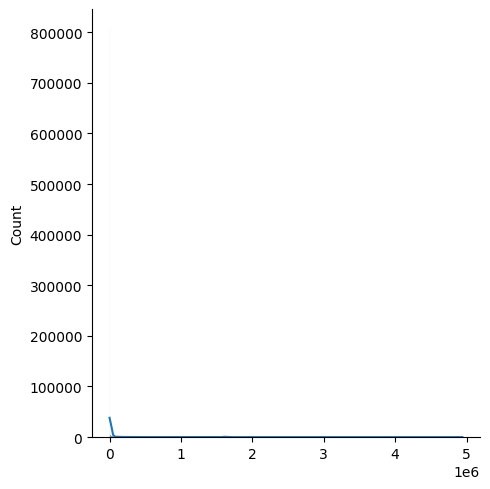

In [48]:
for i in range(dataset.X_data.whitened_data.shape[1]):

    sns.displot(np.array(dataset.X[:, i]), kde=True)
    plt.show()

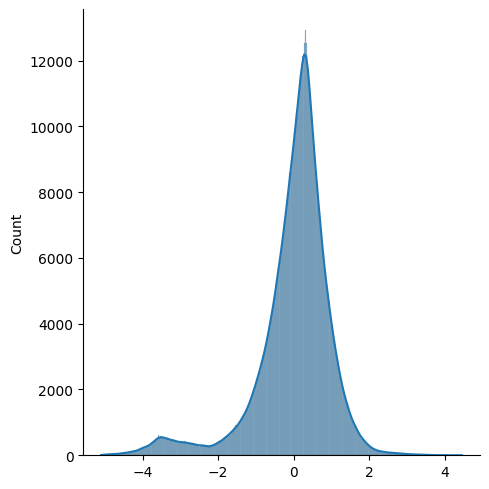

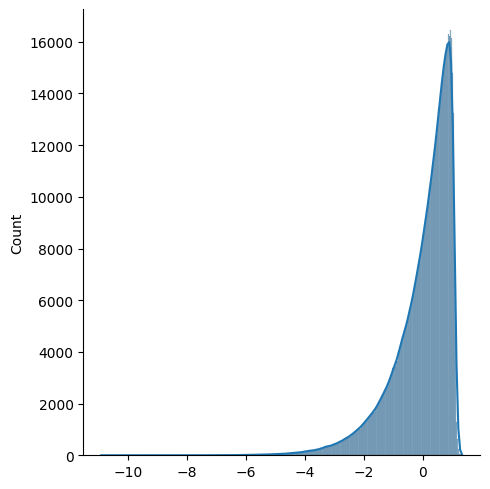

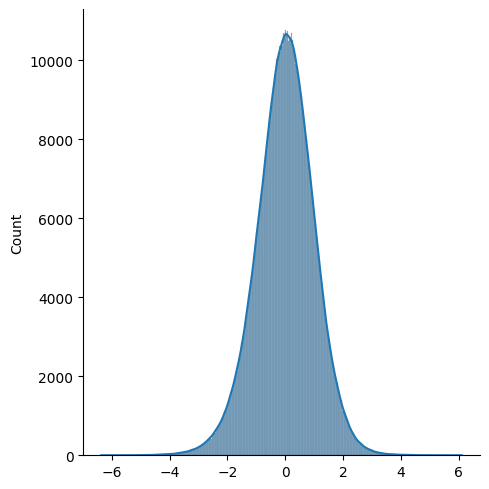

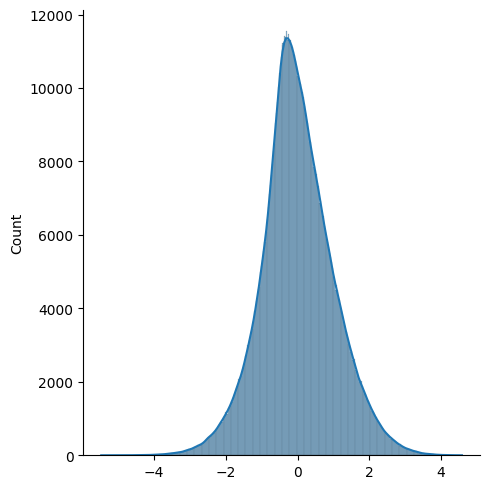

In [43]:
for i in range(dataset.y_data.whitened_data.shape[1]):

    sns.displot(np.array(dataset.y[:, i]), kde=True)
    plt.show()

### Build Flowjax MAF

In [23]:
key_val = 0
key = jax.random.key(key_val)

train_dataset, val_dataset, train_idx, val_idx = dataset.split(key, train_frac=0.8)

config_MAF = {
    "base_dist": "Normal",
    "data_dim": train_dataset.X.shape[1],
    "key": key_val,
    "cond_dim": train_dataset.y.shape[1],  
    "flow_layers": 6,
    "nn_width": 96,
    "nn_depth": 4
}

config = config_MAF
config["type"] = "MAF"

flow = ut.create_flow_from_config(config)

In [24]:
flow, meta = ut.train_flow(flow, train_dataset, val_dataset, patience = 25, batch_size = 4096)

Training:   3%|▎         | 30/1000 [00:23<12:47,  1.26it/s, best_val=1.2124, patience=-1, train=1.1801, val=1.2626] 


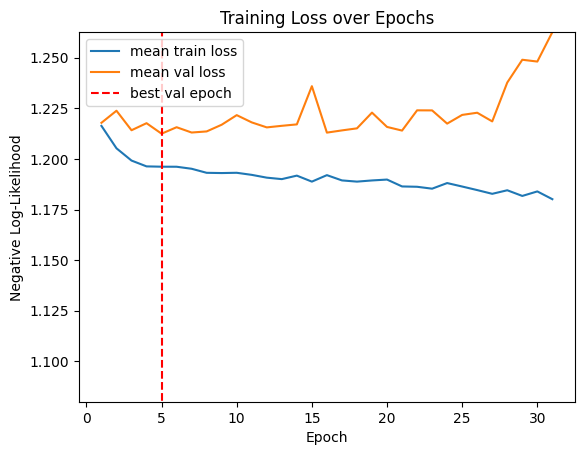

In [25]:
train_losses = meta["train_losses"]
val_losses = meta["val_losses"]

sns.lineplot(x=np.arange(1, len(train_losses) + 1), y=train_losses, label = "mean train loss")
sns.lineplot(x=np.arange(1, len(val_losses) + 1), y=val_losses, label = "mean val loss")
plt.vlines(x = meta["best_epoch"], ymin = min(val_losses)-1, ymax = max(val_losses), color = "red", linestyle = "--", label = "best val epoch")

plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Negative Log-Likelihood")
plt.title("Training Loss over Epochs")
# plt.yscale("log")
plt.ylim(min(val_losses + train_losses)-.1, max(val_losses))
plt.show()

In [27]:
cond = cond_data.whitened_data
S = 10
# 4. sample in whitened x-space
z_key, key = jax.random.split(key)
x_white_samples = flow.sample(z_key, (S,), condition=cond)  # (S, dx)

print(x_white_samples.shape, cond.shape)
x_mean_samples = np.array(x_white_samples.mean(axis = 0))
x_std_samples = np.array(x_white_samples.std(axis = 0))
print(x_mean_samples.shape), print(x_std_samples.shape)

# 5. map samples back to original x-space
x_samples_orig_space = dataset.to_original_space_X(x_mean_samples)
# x_std_samples_orig_space = np.array(x_white_samples.std(axis = 0))
x_std_samples_orig_space = []
for x_ii_samples in x_white_samples:
    x_std_samples_orig_space.append(dataset.to_original_space_X(x_ii_samples))
x_std_samples_orig_space = np.array(x_std_samples_orig_space).std(axis = 0)

(10, 973850, 1) (973850, 4)
(973850, 1)
(973850, 1)


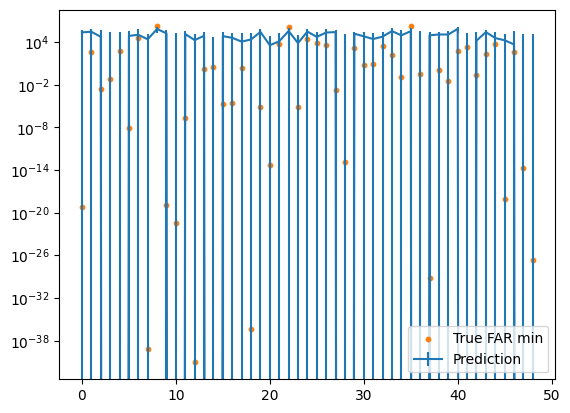

In [30]:
plot_jump = 20000
plt.scatter(range(len(dataset.y_data[::plot_jump])), dataset.X_data.samples[::plot_jump], s = 10, c = "tab:orange", label = "True FAR min")
plt.errorbar(x = range(len(dataset.y_data[::plot_jump])), y = x_samples_orig_space[:, 0][::plot_jump], yerr = x_std_samples_orig_space[:, 0][::plot_jump], label = "Prediction")
# plt.scatter(x = range(len(dataset.y_data[::plot_jump])), y = x_samples_orig_space[:, 0][::plot_jump], label = "Prediction")

plt.legend()
plt.yscale("log")
plt.show()